# POS Hypothesis Explorer

## How to use

1. Make sure your experiment JSON outputs exist under `resources/results/`.
2. Adjust `PROJECT_ROOT` below if needed.
3. Run all cells from top to bottom.
4. Use `SELECTION_METRIC` near the top to choose how “best” is defined.

Recommended metrics:
- `f1` for overall model quality
- `token_accuracy` for straightforward token-level comparison
- `best_val_accuracy` to inspect validation performance


In [304]:
from pathlib import Path

# Adjust if needed
PROJECT_ROOT = Path("/home/dan-gavriluta/Coding/ml-project")
RESULTS_ROOT = PROJECT_ROOT / "resources" / "results"
MODELS_ROOT = PROJECT_ROOT / "resources" / "models"

SELECTION_METRIC = "f1"  # options: f1, token_accuracy, precision, recall, best_val_accuracy

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("Exists:", RESULTS_ROOT.exists())


PROJECT_ROOT: /home/dan-gavriluta/Coding/ml-project
RESULTS_ROOT: /home/dan-gavriluta/Coding/ml-project/resources/results
Exists: True


In [305]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
sns.set_theme(style="whitegrid")

def load_all_result_files(results_root: Path):
    return sorted(results_root.rglob("training_results.json"))

def load_all_runs(results_root: Path):
    files = load_all_result_files(results_root)
    runs = []
    for fp in files:
        with fp.open("r", encoding="utf-8") as f:
            payload = json.load(f)
        if isinstance(payload, dict):
            payload = [payload]
        for run in payload:
            run["_results_file"] = str(fp)
            run["_results_folder"] = str(fp.parent)
            runs.append(run)
    return files, runs

def flatten_run(run):
    row = {
        "name": run.get("name"),
        "model_type": run.get("model_type"),
        "best_val_accuracy": run.get("best_val_accuracy"),
        "best_val_loss": run.get("best_val_loss"),
        "train_time_sec": run.get("train_time_sec"),
        "num_params": run.get("num_params"),
        "epochs_ran": run.get("epochs_ran"),
        "model_path": run.get("model_path"),
        "model_saved": run.get("model_saved"),
        "_results_file": run.get("_results_file"),
        "_results_folder": run.get("_results_folder"),
    }

    tm = run.get("test_metrics", {})
    for k, v in tm.items():
        row[k] = v

    cfg = run.get("config", {})
    for k, v in cfg.items():
        row[f"cfg_{k}"] = v

    dm = run.get("dataset_meta", {})
    row["group"] = cfg.get("group")
    row["hypothesis"] = cfg.get("hypothesis")
    row["sentences"] = dm.get("sentences", cfg.get("sentences"))
    row["maxlen"] = dm.get("maxlen", cfg.get("maxlen"))
    row["split_seed"] = dm.get("split_seed", cfg.get("split_seed"))
    row["run_seed"] = dm.get("seed", cfg.get("seed"))
    row["vocab_size"] = dm.get("vocab_size", cfg.get("vocab_size"))
    row["num_tags"] = dm.get("num_tags", cfg.get("num_tags"))

    return row

def runs_to_df(runs):
    if not runs:
        return pd.DataFrame()
    df = pd.DataFrame([flatten_run(r) for r in runs])

    numeric_cols = [
        "best_val_accuracy", "best_val_loss", "train_time_sec", "num_params", "epochs_ran",
        "token_accuracy", "precision", "recall", "f1",
        "sentences", "maxlen", "split_seed", "run_seed", "vocab_size", "num_tags",
        "cfg_lr", "cfg_dropout", "cfg_batch_size", "cfg_embed_dim", "cfg_ff_dim",
        "cfg_num_layers", "cfg_num_heads", "cfg_lstm_units", "cfg_lstm_layers",
        "cfg_lr_warmup_steps",
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def get_hypothesis(df, hypothesis_name):
    return df[df["hypothesis"] == hypothesis_name].copy()

def show_top(df, metric="f1", n=10):
    cols = [
        "name", "group", "model_type", metric,
        "token_accuracy", "best_val_accuracy", "train_time_sec",
        "num_params", "sentences", "maxlen", "split_seed", "run_seed"
    ]
    cols = [c for c in cols if c in df.columns]
    return df.sort_values(metric, ascending=False)[cols].head(n).reset_index(drop=True)

def plot_bar(df_group, metric="f1", title=None, hue="model_type", figsize=(12, 5)):
    if df_group.empty:
        print("No rows for this plot.")
        return
    order = df_group.sort_values(metric, ascending=False)["name"]
    plt.figure(figsize=figsize)
    sns.barplot(data=df_group, x="name", y=metric, hue=hue, order=order)
    plt.xticks(rotation=35, ha="right")
    plt.title(title or f"{metric} by run")
    plt.tight_layout()
    plt.show()

def plot_line(df_group, x, y="f1", hue="model_type", marker="o", title=None, figsize=(10, 5)):
    if df_group.empty:
        print("No rows for this plot.")
        return
    plt.figure(figsize=figsize)
    sns.lineplot(data=df_group.sort_values([hue, x]), x=x, y=y, hue=hue, marker=marker)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

def plot_histories(runs, hypothesis_name, metric="val_accuracy", figsize=(10, 5)):
    plt.figure(figsize=figsize)
    used = False
    for run in runs:
        cfg = run.get("config", {})
        if cfg.get("hypothesis") != hypothesis_name:
            continue
        hist = run.get("history", {})
        vals = hist.get(metric, [])
        if vals:
            used = True
            plt.plot(range(1, len(vals) + 1), vals, label=run.get("name"))
    if not used:
        print("No history found for this hypothesis/metric.")
        return
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"{hypothesis_name}: {metric}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def annotate_scatter(df_group, x="train_time_sec", y="f1", figsize=(8, 5), title=None):
    if df_group.empty:
        print("No rows for this plot.")
        return
    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_group, x=x, y=y, hue="model_type", s=80)
    for _, row in df_group.iterrows():
        plt.annotate(row["name"], (row[x], row[y]), fontsize=8)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

def grouped_summary(df_group, by, metric="f1"):
    if df_group.empty:
        return pd.DataFrame()
    return (
        df_group.groupby(by, dropna=False)[metric]
        .agg(["count", "mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

def plot_history_range(runs, hypothesis_name, metric="val_accuracy", figsize=(10, 5)):
    """Plot mean history with min-max range shading per model type."""
    rows = []
    for run in runs:
        cfg = run.get("config", {})
        if cfg.get("hypothesis") != hypothesis_name:
            continue

        vals = run.get("history", {}).get(metric, [])
        if not vals:
            continue

        model_type = run.get("model_type") or cfg.get("model_type", "unknown")
        for epoch, value in enumerate(vals, start=1):
            rows.append({"epoch": epoch, "value": value, "model_type": model_type})

    if not rows:
        print("No history found for this hypothesis/metric.")
        return

    hist_df = pd.DataFrame(rows)
    plt.figure(figsize=figsize)

    for model_type, group in hist_df.groupby("model_type"):
        stats = group.groupby("epoch")["value"].agg(["mean", "min", "max"]).reset_index()
        plt.plot(stats["epoch"], stats["mean"], label=f"{model_type} mean")
        plt.fill_between(stats["epoch"], stats["min"], stats["max"], alpha=0.2, label=f"{model_type} range")

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"{hypothesis_name}: {metric}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def practical_score(df, metric="f1", time_penalty=0.001):
    out = df.copy()
    out["practical_score"] = out[metric] - time_penalty * out["train_time_sec"].fillna(0)
    return out

files, runs = load_all_runs(RESULTS_ROOT)
df = runs_to_df(runs)

print(f"Found {len(files)} result file(s)")
print(f"Loaded {len(runs)} run(s)")

Found 8 result file(s)
Loaded 80 run(s)


In [306]:
import keras

def load_model_and_tags(model_path, models_root):
    """Load a saved model and extract tag information from the results."""
    if not model_path:
        return None, None
    
    full_path = models_root / model_path
    if not full_path.exists():
        return None, None
    
    try:
        model = keras.models.load_model(full_path)
        return model, None
    except Exception as e:
        print(f"Error loading model from {full_path}: {e}")
        return None, None

def get_tag_performance(df_subset, models_root):
    """Extract per-tag performance from test results if available."""
    tag_data = []
    
    for _, row in df_subset.iterrows():
        results_folder = row.get("_results_folder")
        if not results_folder:
            continue
            
        results_path = Path(results_folder) / "training_results.json"
        if not results_path.exists():
            continue
            
        with open(results_path, "r") as f:
            results = json.load(f)
            if isinstance(results, dict):
                results = [results]
            
            for result in results:
                if result.get("name") == row["name"]:
                    tag_metrics = result.get("test_metrics", {}).get("per_tag", {})
                    if tag_metrics:
                        for tag, metrics in tag_metrics.items():
                            tag_data.append({
                                "name": row["name"],
                                "model_type": row["model_type"],
                                "hypothesis": row["hypothesis"],
                                "tag": tag,
                                "f1": metrics.get("f1", 0),
                                "precision": metrics.get("precision", 0),
                                "recall": metrics.get("recall", 0),
                                "support": metrics.get("support", 0)
                            })
    
    return pd.DataFrame(tag_data) if tag_data else pd.DataFrame()

def plot_tag_performance(df_subset, models_root, metric="f1", top_n=15, figsize=(14, 6)):
    """Plot per-tag performance as bar charts."""
    tag_df = get_tag_performance(df_subset, models_root)
    
    if tag_df.empty:
        print("No per-tag performance data found in results.")
        return
    
    # Get top N tags by average support across all models
    tag_support = tag_df.groupby("tag")["support"].mean().sort_values(ascending=False)
    top_tags = tag_support.head(top_n).index.tolist()
    
    # Filter to top tags
    tag_df_filtered = tag_df[tag_df["tag"].isin(top_tags)]
    
    if tag_df_filtered.empty:
        print("No tag data after filtering.")
        return
    
    # Calculate average performance per tag and model type
    tag_summary = tag_df_filtered.groupby(["tag", "model_type"])[metric].mean().reset_index()
    
    plt.figure(figsize=figsize)
    
    # Sort tags by average performance
    tag_order = tag_df_filtered.groupby("tag")[metric].mean().sort_values(ascending=False).index
    
    sns.barplot(data=tag_summary, x="tag", y=metric, hue="model_type", order=tag_order)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Per-Tag {metric.upper()} Performance (Top {top_n} tags by frequency)")
    plt.ylabel(f"Average {metric.upper()}")
    plt.xlabel("POS Tag")
    plt.legend(title="Model Type")
    plt.tight_layout()
    plt.show()
    
    return tag_df_filtered

print("Tag analysis functions loaded.")

Tag analysis functions loaded.


In [307]:
def show_final_tables(df_subset, hypothesis_label, metric=SELECTION_METRIC):
    """Display richer final summary tables for a hypothesis subset."""
    if df_subset.empty:
        print(f"No data for {hypothesis_label}.")
        return

    cols = [
        "name", "model_type", "sentences", "cfg_lr",
        metric, "token_accuracy", "best_val_accuracy", "best_val_loss",
        "train_time_sec", "num_params", "epochs_ran"
    ]
    cols = [c for c in cols if c in df_subset.columns]

    display(Markdown(f"#### {hypothesis_label} leaderboard (top 10 by {metric})"))
    display(
        df_subset.sort_values(metric, ascending=False)[cols]
        .head(10)
        .reset_index(drop=True)
    )

    agg_spec = {metric: ["mean", "std", "max"], "token_accuracy": ["mean", "std"], "train_time_sec": "mean"}
    agg_spec = {k: v for k, v in agg_spec.items() if k in df_subset.columns}
    group_cols = [c for c in ["model_type", "cfg_lr"] if c in df_subset.columns]

    if group_cols and agg_spec:
        display(Markdown(f"#### {hypothesis_label} grouped summary ({', '.join(group_cols)})"))
        grouped = df_subset.groupby(group_cols, dropna=False).agg(agg_spec)
        grouped.columns = ["_".join(col).strip("_") for col in grouped.columns.to_flat_index()]
        grouped = grouped.reset_index().sort_values(f"{metric}_mean", ascending=False)
        display(grouped)

    if all(c in df_subset.columns for c in ["model_type", "sentences", metric]):
        display(Markdown(f"#### {hypothesis_label} per-sentence winner"))
        winners = (
            df_subset.sort_values(metric, ascending=False)
            .groupby("sentences", as_index=False)
            .first()[["sentences", "name", "model_type", "cfg_lr", metric]]
        )
        winners = winners.sort_values("sentences").reset_index(drop=True)
        display(winners)

def show_per_tag_tables(tag_df, hypothesis_label, metric="f1"):
    """Display additional per-tag analytical tables."""
    if tag_df is None or tag_df.empty:
        print(f"No per-tag rows for {hypothesis_label}.")
        return

    display(Markdown(f"#### {hypothesis_label} hardest frequent tags"))
    hard_tags = (
        tag_df[tag_df["support"] >= 20]
        .groupby("tag", dropna=False)
        .agg(avg_f1=("f1", "mean"), avg_precision=("precision", "mean"), avg_recall=("recall", "mean"), avg_support=("support", "mean"), runs=("name", "nunique"))
        .sort_values("avg_f1", ascending=True)
        .head(10)
        .reset_index()
    )
    display(hard_tags)

    if "model_type" in tag_df.columns:
        display(Markdown(f"#### {hypothesis_label} tag spread by model family"))
        family_tags = (
            tag_df.groupby(["model_type", "tag"], dropna=False)
            .agg(mean_f1=("f1", "mean"), std_f1=("f1", "std"), support=("support", "mean"))
            .reset_index()
            .sort_values(["model_type", "mean_f1"], ascending=[True, True])
        )
        display(family_tags.head(20).reset_index(drop=True))

In [308]:
if df.empty:
    print("No results found. Run experiments first.")
else:
    display(Markdown("### Discovered result files"))
    display(pd.DataFrame({"results_file": [str(f) for f in files]}))

    display(Markdown("### Overall top runs"))
    display(show_top(df, metric=SELECTION_METRIC, n=15))

    display(Markdown("### Run counts by group"))
    group_counts = df.groupby(["group", "model_type"]).size().reset_index(name="runs")
    display(group_counts.sort_values(["group", "model_type"]).reset_index(drop=True))


### Discovered result files

,results_file
0,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_high_lr_small_ds/training_results.json
1,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_low_lr_small_ds/training_results.json
2,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_medium_lr_small_ds/training_results.json
3,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_2_high_lr_small_ds/training_results.json
4,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_2_low_lr_small_ds/training_results.json
5,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_2_medium_lr_small_ds/training_results.json
6,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_3_best_lr_big_ds/training_results.json
7,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_3_best_lr_huge_ds/training_results.json


### Overall top runs

,name,group,model_type,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params,sentences,maxlen,split_seed,run_seed
0,A_lstm_stronger_s105000,A_baseline_family_comparison,lstm,0.983555,0.983715,0.985151,372.743220,6213044,105000,30,42,42
1,A_lstm_stronger_s93000,A_baseline_family_comparison,lstm,0.980967,0.981233,0.982428,327.189619,6093619,93000,30,42,42
2,A_lstm_stronger_s81000,A_baseline_family_comparison,lstm,0.977097,0.977240,0.979328,255.156552,5939503,81000,30,42,42
3,A_lstm_stronger_s69000,A_baseline_family_comparison,lstm,0.975145,0.975336,0.977120,218.087108,5732780,69000,30,42,42
4,A_lstm_stronger_s57000,A_baseline_family_comparison,lstm,0.957560,0.958070,0.958710,180.386126,6645430,57000,30,42,42
5,A_lstm_stronger_s57000,A_baseline_family_comparison,lstm,0.957560,0.958070,0.958710,179.049430,6645430,57000,30,42,42
6,A_transformer_medium_s105000,A_baseline_family_comparison,transformer,0.957443,0.958040,0.975443,281.642526,6326708,105000,30,42,42
7,A_lstm_stronger_s46000,A_baseline_family_comparison,lstm,0.956559,0.957203,0.956404,144.668601,6167971,46000,30,42,42
8,A_lstm_stronger_s34000,A_baseline_family_comparison,lstm,0.955470,0.955892,0.955991,119.403538,5489294,34000,30,42,42
9,A_transformer_medium_s93000,A_baseline_family_comparison,transformer,0.952425,0.953269,0.972282,234.976030,6207411,93000,30,42,42


### Run counts by group

,group,model_type,runs
0,A_baseline_family_comparison,lstm,40
1,A_baseline_family_comparison,transformer,40


## Overall interpretation guide

Use these rules while reading the plots:

- **Higher `f1` / `token_accuracy` is better**
- **Lower `best_val_loss` is better**
- **Lower `train_time_sec` is better**
- If one family wins by only a tiny margin but is much slower, check the practical tradeoff
- For groups that vary data size or max length, compare trends, not just one isolated bar
- For robustness, prefer **mean performance + low variance** over one lucky best run


In [309]:
leaderboard_cols = [
    "name", "group", "model_type",
    "token_accuracy", "f1", "precision", "recall",
    "best_val_accuracy", "best_val_loss",
    "train_time_sec", "epochs_ran",
]

config_cols = [
    "name", "model_type",
    "num_params",
    "cfg_embed_dim", "cfg_num_heads", "cfg_ff_dim", "cfg_num_layers",
    "cfg_lstm_units", "cfg_lstm_layers", "cfg_dropout", "cfg_lr",
    "cfg_lr_warmup_steps", "cfg_batch_size",
]

meta_cols = [
    "name", "model_type",
    "sentences", "maxlen", "split_seed", "run_seed",
    "vocab_size", "num_tags",
    "predict_batch_size_used", "predict_device",
]

# Hypothesis 1 — Learning-Rate Preference by Architecture

**Research question**
Do transformer and LSTM architectures prefer different learning-rate ranges under comparable capacity?

**Alternative hypothesis (H1)**
Transformer models perform best at lower learning rates than LSTM models under the same training protocol.

**Assumptions**
- Train/test split procedure is identical across runs.
- Reported metrics come from comparable sentence budgets (5000 to 13000).
- Architecture capacity is fixed within this hypothesis (medium transformer vs stronger LSTM).

**Success criteria**
- Transformer best mean token accuracy appears at 1e-5 or 1e-4.
- LSTM best mean token accuracy appears at 1e-4 or 1e-3.
- In each family, best-vs-worst LR gap is at least 1.0 token-accuracy point.

In [310]:
# Filter data for Hypothesis 1
h1_data = get_hypothesis(df, "H1_learning_rate_impact")

if h1_data.empty:
    print("No H1 data found yet. Run experiments with hypothesis='H1_learning_rate_impact' in config.")
else:
    print(f"Found {len(h1_data)} runs for Hypothesis 1")
    display(Markdown("### Hypothesis 1 — All runs"))
    display_cols = [
        "name", "model_type", "sentences", "cfg_lr",
        "f1", "token_accuracy", "best_val_accuracy",
        "train_time_sec", "num_params"
    ]
    display_cols = [c for c in display_cols if c in h1_data.columns]
    display(h1_data[display_cols].sort_values(["sentences", "cfg_lr", "model_type"]).reset_index(drop=True))

Found 30 runs for Hypothesis 1


### Hypothesis 1 — All runs

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params
0,A_lstm_stronger_s5000,lstm,5000,0.00001,0.291766,0.360625,0.368124,100.431219,1490323
1,A_transformer_medium_s5000,transformer,5000,0.00001,0.794450,0.797663,0.911833,27.889256,1624595
2,A_lstm_stronger_s5000,lstm,5000,0.00010,0.879871,0.883341,0.887887,60.364871,1490323
3,A_transformer_medium_s5000,transformer,5000,0.00010,0.850006,0.850356,0.936042,19.405027,1624595
4,A_lstm_stronger_s5000,lstm,5000,0.00100,0.906864,0.907268,0.919126,26.354384,1490323
5,A_transformer_medium_s5000,transformer,5000,0.00100,0.852082,0.853122,0.939083,17.330936,1624595
6,A_lstm_stronger_s7000,lstm,7000,0.00001,0.387216,0.460553,0.474075,135.472918,1896083
7,A_transformer_medium_s7000,transformer,7000,0.00001,0.826508,0.829102,0.916399,24.625690,2030355
8,A_lstm_stronger_s7000,lstm,7000,0.00010,0.904526,0.906921,0.902446,81.498677,1896083
9,A_transformer_medium_s7000,transformer,7000,0.00010,0.853524,0.854585,0.930655,13.220135,2030355


### Interpretation

**Expected outcomes:**
1. **Learning rate preference**:
   - LSTM should perform best at higher LR (e.g., 1e-3)
   - Transformer should perform best at lower LR (e.g., 1e-4 or 5e-4)

2. **Data scaling**:
   - At low data (500-2000 sentences): LSTM and Transformer should be competitive
   - At high data (5000-12543 sentences): Transformer should pull ahead significantly
   - The gap should widen as data increases

3. **Combined effect**:
   - Transformer at low LR + high data should be the winning combination
   - LSTM's advantage (if any) should be limited to high LR + low data scenarios

### Visualization 3: Heatmap of LR × Data Size

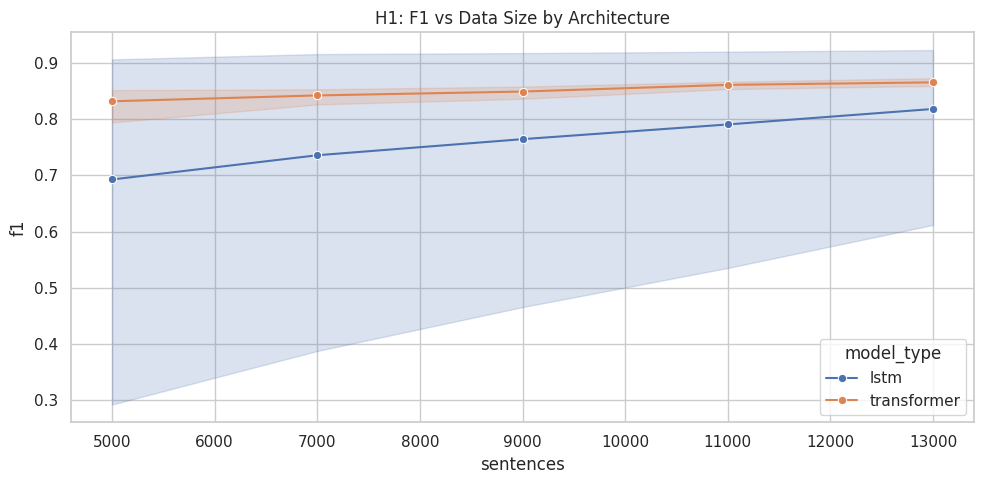

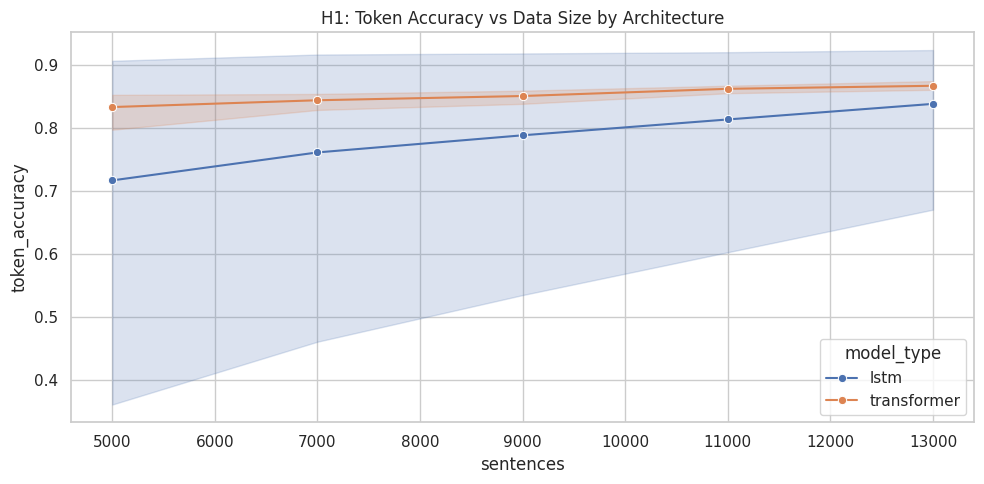

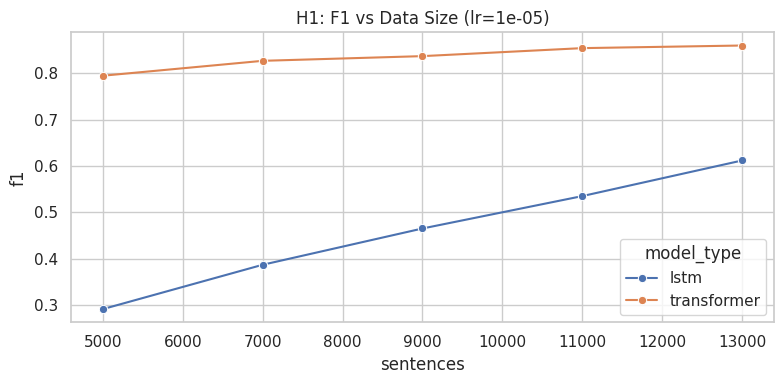

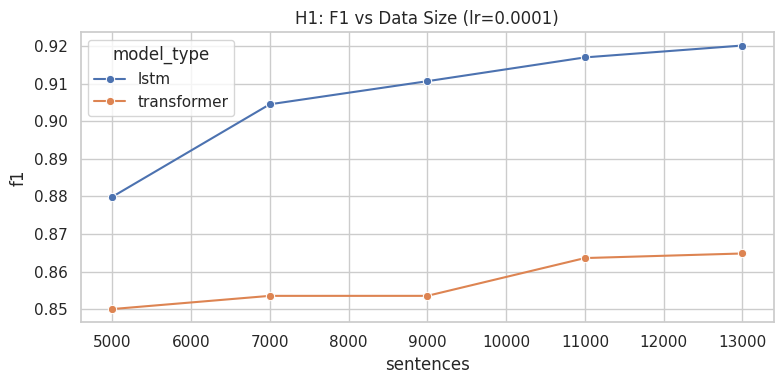

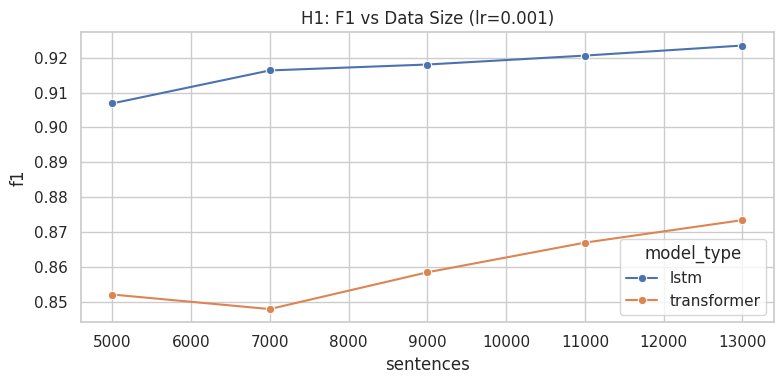

In [311]:
if not h1_data.empty:
    plot_line(
        h1_data,
        x="sentences",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H1: {SELECTION_METRIC.upper()} vs Data Size by Architecture",
        figsize=(10, 5)
    )

    if "token_accuracy" in h1_data.columns:
        plot_line(
            h1_data,
            x="sentences",
            y="token_accuracy",
            hue="model_type",
            title="H1: Token Accuracy vs Data Size by Architecture",
            figsize=(10, 5)
        )

    # Also show for each learning rate separately
    for lr in sorted(h1_data["cfg_lr"].unique()):
        subset = h1_data[h1_data["cfg_lr"] == lr]
        if len(subset) > 0:
            plot_line(
                subset,
                x="sentences",
                y=SELECTION_METRIC,
                hue="model_type",
                title=f"H1: {SELECTION_METRIC.upper()} vs Data Size (lr={lr})",
                figsize=(8, 4)
            )

            lr_runs = [
                r for r in runs
                if r.get("config", {}).get("hypothesis") == "H1_learning_rate_impact"
                and float(r.get("config", {}).get("lr", np.nan)) == float(lr)
            ]

### Final tables 

In [312]:
if not h1_data.empty:
    show_final_tables(h1_data, "H1", metric=SELECTION_METRIC)

#### H1 leaderboard (top 10 by f1)

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran
0,A_lstm_stronger_s13000,lstm,13000,0.0010,0.923478,0.924362,0.927435,0.253649,45.453706,2506771,9
1,A_lstm_stronger_s11000,lstm,11000,0.0010,0.920589,0.920961,0.921378,0.271500,38.757520,2320403,9
2,A_lstm_stronger_s13000,lstm,13000,0.0001,0.920181,0.921397,0.922900,0.261786,154.793291,2506771,30
3,A_lstm_stronger_s9000,lstm,9000,0.0010,0.918029,0.918956,0.919356,0.286669,35.526967,2137747,10
4,A_lstm_stronger_s11000,lstm,11000,0.0001,0.917015,0.918156,0.916946,0.282226,127.021598,2320403,30
5,A_lstm_stronger_s7000,lstm,7000,0.0010,0.916328,0.917241,0.918269,0.284815,30.838678,1896083,11
6,A_lstm_stronger_s9000,lstm,9000,0.0001,0.910680,0.912701,0.911033,0.306191,104.141967,2137747,30
7,A_lstm_stronger_s5000,lstm,5000,0.0010,0.906864,0.907268,0.919126,0.299032,26.354384,1490323,12
8,A_lstm_stronger_s7000,lstm,7000,0.0001,0.904526,0.906921,0.902446,0.331705,81.498677,1896083,30
9,A_lstm_stronger_s5000,lstm,5000,0.0001,0.879871,0.883341,0.887887,0.419260,60.364871,1490323,30


#### H1 grouped summary (model_type, cfg_lr)

,model_type,cfg_lr,f1_mean,f1_std,f1_max,token_accuracy_mean,token_accuracy_std,train_time_sec_mean
2,lstm,0.00100,0.917058,0.006306,0.923478,0.917758,0.006435,35.386251
1,lstm,0.00010,0.906455,0.016033,0.920181,0.908503,0.015105,105.564081
5,transformer,0.00100,0.859761,0.010483,0.873419,0.861080,0.010329,13.168717
4,transformer,0.00010,0.857091,0.006660,0.864809,0.858287,0.006982,15.128610
3,transformer,0.00001,0.834181,0.025838,0.859484,0.836487,0.025223,30.149986
0,lstm,0.00001,0.458255,0.124802,0.611803,0.525862,0.120946,173.948880


#### H1 per-sentence winner

,sentences,name,model_type,cfg_lr,f1
0,5000,A_lstm_stronger_s5000,lstm,0.001,0.906864
1,7000,A_lstm_stronger_s7000,lstm,0.001,0.916328
2,9000,A_lstm_stronger_s9000,lstm,0.001,0.918029
3,11000,A_lstm_stronger_s11000,lstm,0.001,0.920589
4,13000,A_lstm_stronger_s13000,lstm,0.001,0.923478


### Hypothesis 1 — Per-Tag Performance

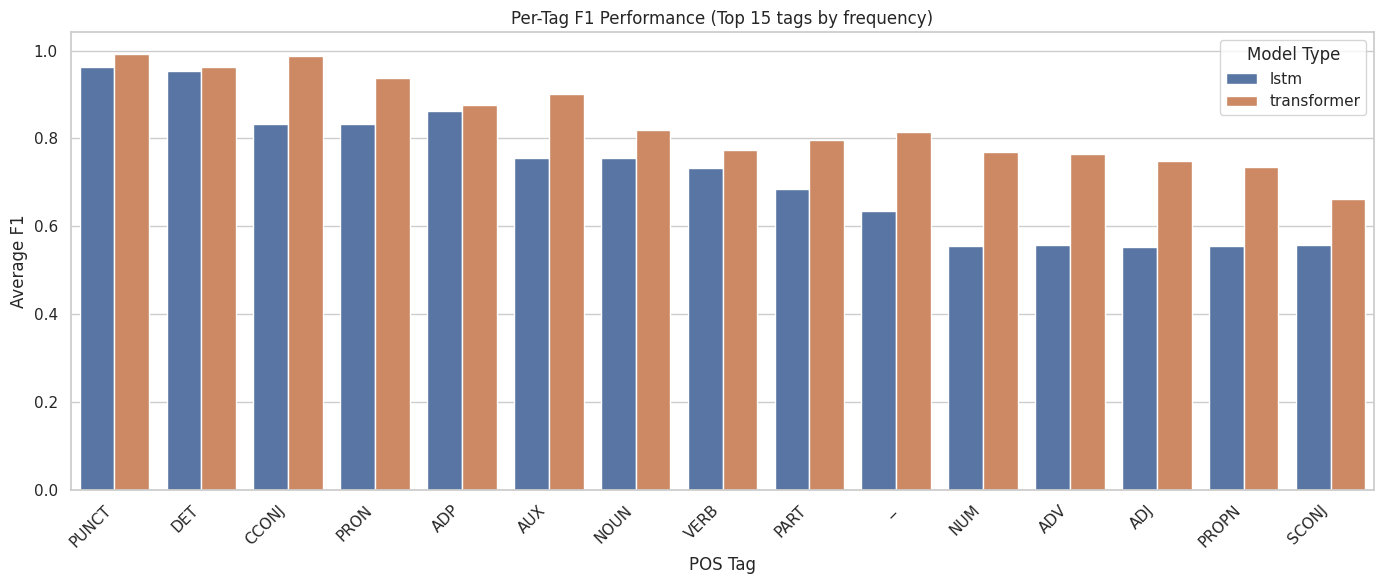

#### Tag-level comparison

**Best transformer: A_transformer_medium_s13000**

,tag,f1,precision,recall,support
0,NOUN,0.850697,0.815725,0.888802,6385
1,NOUN,0.835958,0.816485,0.856382,6385
2,NOUN,0.843691,0.820172,0.868598,6385
3,PUNCT,0.993448,0.990205,0.996713,4564
4,PUNCT,0.993116,0.990626,0.995618,4564
5,PUNCT,0.993881,0.991282,0.996494,4564
6,VERB,0.822766,0.829279,0.816354,4427
7,VERB,0.797742,0.813866,0.782245,4427
8,VERB,0.802871,0.810071,0.795799,4427
9,PRON,0.950894,0.952516,0.949277,3529


**Best lstm: A_lstm_stronger_s13000**

,tag,f1,precision,recall,support
0,NOUN,0.902339,0.889769,0.915270,6385
1,NOUN,0.595704,0.452105,0.872984,6385
2,NOUN,0.898211,0.873926,0.923884,6385
3,PUNCT,0.993657,0.991921,0.995399,4564
4,PUNCT,0.966561,0.967303,0.965819,4564
5,PUNCT,0.993660,0.991492,0.995837,4564
6,VERB,0.911435,0.904741,0.918229,4427
7,VERB,0.562571,0.457766,0.729614,4427
8,VERB,0.906153,0.919535,0.893156,4427
9,PRON,0.982868,0.982173,0.983565,3529


#### H1 hardest frequent tags

,tag,avg_f1,avg_precision,avg_recall,avg_support,runs
0,SCONJ,0.609687,0.669592,0.578558,534.8,10
1,PROPN,0.645052,0.758571,0.632476,2004.2,10
2,ADJ,0.650827,0.682128,0.645954,1531.4,10
3,ADV,0.660561,0.769202,0.619417,1177.8,10
4,NUM,0.661869,0.709428,0.621810,567.0,10
5,_,0.725108,0.795731,0.686062,284.6,10
6,PART,0.740865,0.757895,0.795733,697.4,10
7,VERB,0.753424,0.745069,0.771704,2877.8,10
8,NOUN,0.788160,0.742408,0.870218,4452.8,10
9,AUX,0.828470,0.873681,0.834327,1569.4,10


#### H1 tag spread by model family

,model_type,tag,mean_f1,std_f1,support
0,lstm,ADJ,0.552252,0.403409,1531.4
1,lstm,NUM,0.554625,0.409579,567.0
2,lstm,PROPN,0.554639,0.385329,2004.2
3,lstm,ADV,0.557099,0.400573,1177.8
4,lstm,SCONJ,0.558285,0.380694,534.8
5,lstm,_,0.634878,0.463947,284.6
6,lstm,PART,0.684236,0.403511,697.4
7,lstm,VERB,0.732212,0.240831,2877.8
8,lstm,AUX,0.756486,0.357891,1569.4
9,lstm,NOUN,0.756578,0.198967,4452.8


In [313]:
display(Markdown("### Hypothesis 1 — Per-Tag Performance"))

if not h1_data.empty:
    tag_df_h1 = plot_tag_performance(h1_data, MODELS_ROOT, metric=SELECTION_METRIC, top_n=15)

    if tag_df_h1 is not None and not tag_df_h1.empty:
        display(Markdown("#### Tag-level comparison"))
        for mt in h1_data["model_type"].unique():
            best_run = h1_data[h1_data["model_type"] == mt].nlargest(1, SELECTION_METRIC)
            if not best_run.empty:
                best_name = best_run.iloc[0]["name"]
                best_tags = tag_df_h1[tag_df_h1["name"] == best_name].nlargest(10, "support")
                if not best_tags.empty:
                    display(Markdown(f"**Best {mt}: {best_name}**"))
                    display(best_tags[["tag", "f1", "precision", "recall", "support"]].reset_index(drop=True))

        show_per_tag_tables(tag_df_h1, "H1", metric=SELECTION_METRIC)
else:
    print("No H1 data for tag analysis.")

# Hypothesis 2 — Small Models Are More LR-Sensitive

**Research question**
Are smaller models more sensitive to learning-rate changes than larger models?

**Alternative hypothesis (H2)**
Small models show larger performance variance across learning rates than medium-capacity models.

**Assumptions**
- Optimization setup is consistent across small and medium runs.
- Sentence budgets are matched across LR sweeps.
- Sensitivity is measured with token accuracy, not a single lucky run.

**Success criteria**
- Sensitivity per architecture is: max(token_accuracy over LR) - min(token_accuracy over LR).
- H2 is supported if small-model sensitivity exceeds medium-model sensitivity for both transformer and LSTM families.
- Direction should be consistent across most sentence budgets, not only one point.

In [314]:
# Filter data for Hypothesis 2
h2_data = get_hypothesis(df, "H2_small_models")

if h2_data.empty:
    print("No H2 data found yet. Run experiments with hypothesis='H2_small_models' in config.")
else:
    print(f"Found {len(h2_data)} runs for Hypothesis 2")
    display(Markdown("### Hypothesis 2 — All runs"))
    display_cols = [
        "name", "model_type", "sentences", "cfg_lr",
        "f1", "token_accuracy", "best_val_accuracy",
        "train_time_sec", "num_params"
    ]
    display_cols = [c for c in display_cols if c in h2_data.columns]
    display(h2_data[display_cols].sort_values(["sentences", "cfg_lr", "model_type"]).reset_index(drop=True))

Found 30 runs for Hypothesis 2


### Hypothesis 2 — All runs

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params
0,A_lstm_stronger_s5000,lstm,5000,0.00001,0.116130,0.219764,0.230328,95.307095,357683
1,A_transformer_small_s5000,transformer,5000,0.00001,0.654708,0.669594,0.855417,17.494296,324051
2,A_lstm_stronger_s5000,lstm,5000,0.00010,0.695722,0.728719,0.735884,58.803769,357683
3,A_transformer_small_s5000,transformer,5000,0.00010,0.844629,0.844617,0.934250,14.436019,324051
4,A_lstm_small_s5000,lstm,5000,0.00100,0.905249,0.905816,0.917304,30.787564,357683
5,A_transformer_small_s5000,transformer,5000,0.00100,0.852691,0.852984,0.939833,11.491367,324051
6,A_lstm_stronger_s7000,lstm,7000,0.00001,0.162506,0.243189,0.250487,128.616955,459123
7,A_transformer_small_s7000,transformer,7000,0.00001,0.726051,0.735877,0.874048,18.419464,425491
8,A_lstm_stronger_s7000,lstm,7000,0.00010,0.805339,0.821326,0.822055,78.165195,459123
9,A_transformer_small_s7000,transformer,7000,0.00010,0.851724,0.853020,0.929464,13.760587,425491


### Interpretation

**Expected outcomes:**
1. **Small model efficiency**:
   - Lower training time due to fewer parameters
   - Competitive performance with proper tuning
   
2. **Learning rate sensitivity**:
   - Each architecture should have an optimal LR
   - Small models may be more sensitive to LR choice

3. **Scaling behavior**:
   - Performance should improve with more data
   - Gap between LSTM and Transformer may be smaller with small models

### Visualization: Performance vs Data Size

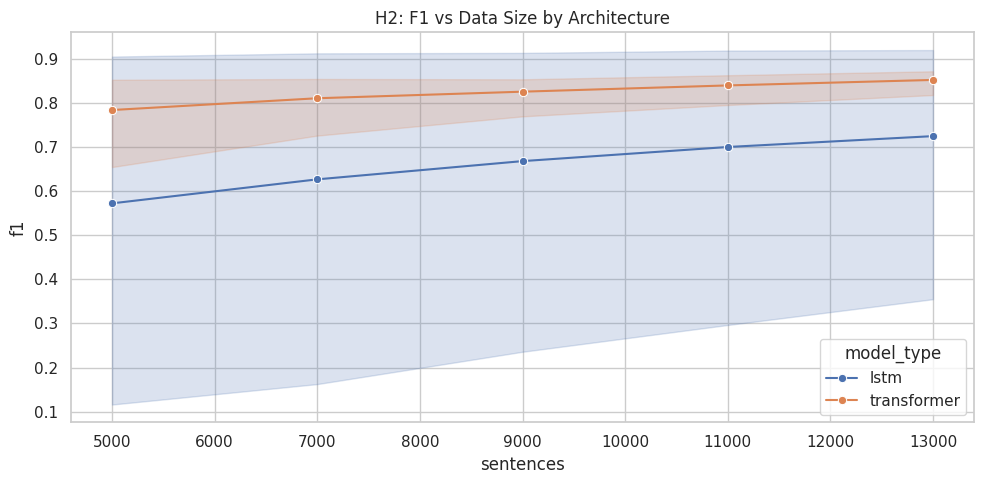

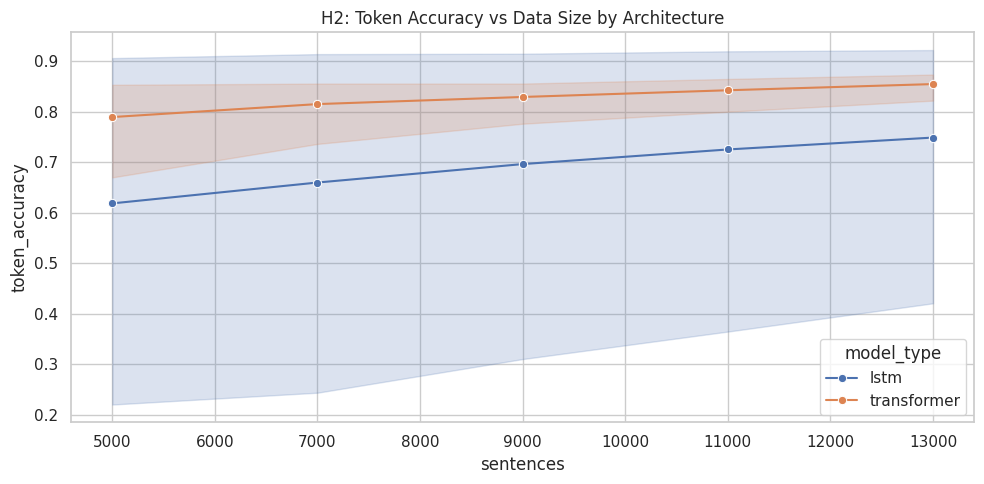

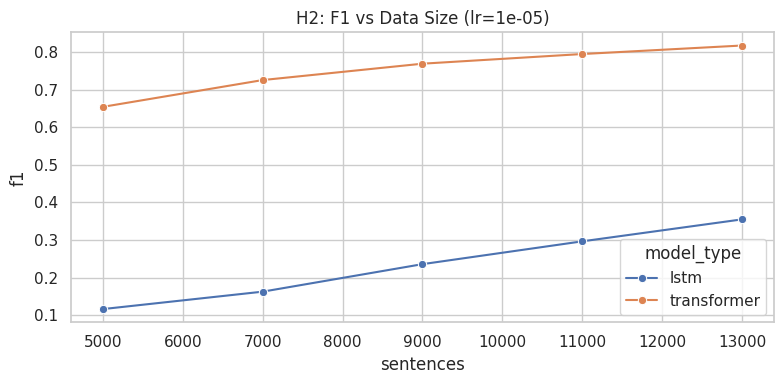

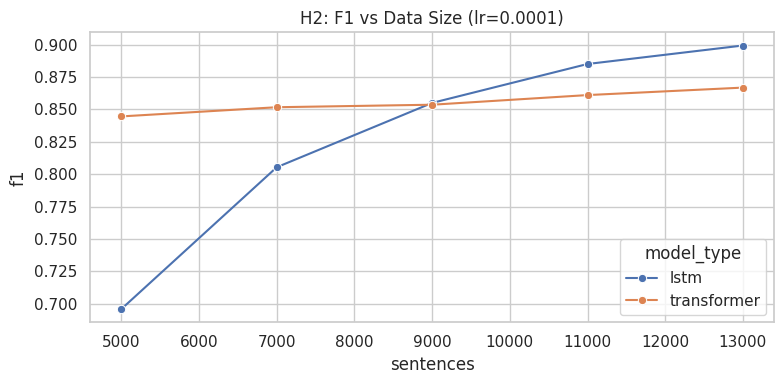

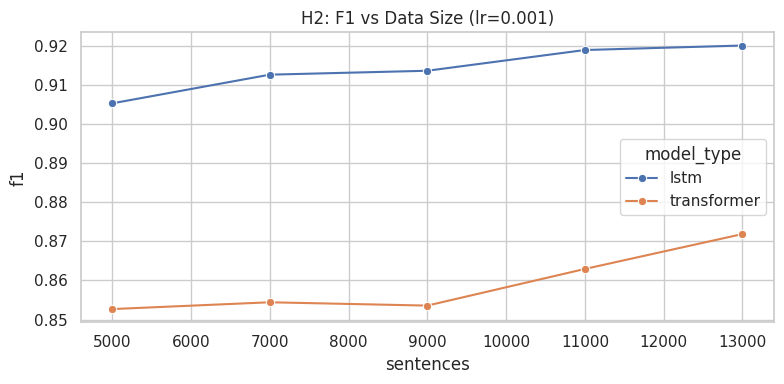

In [315]:
if not h2_data.empty:
    plot_line(
        h2_data,
        x="sentences",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H2: {SELECTION_METRIC.upper()} vs Data Size by Architecture",
        figsize=(10, 5)
    )

    if "token_accuracy" in h2_data.columns:
        plot_line(
            h2_data,
            x="sentences",
            y="token_accuracy",
            hue="model_type",
            title="H2: Token Accuracy vs Data Size by Architecture",
            figsize=(10, 5)
        )

    # Show for each learning rate separately
    for lr in sorted(h2_data["cfg_lr"].unique()):
        subset = h2_data[h2_data["cfg_lr"] == lr]
        if len(subset) > 0:
            plot_line(
                subset,
                x="sentences",
                y=SELECTION_METRIC,
                hue="model_type",
                title=f"H2: {SELECTION_METRIC.upper()} vs Data Size (lr={lr})",
                figsize=(8, 4)
            )

### Final tables

In [316]:
if not h2_data.empty:
    show_final_tables(h2_data, "H2", metric=SELECTION_METRIC)

    if all(c in h2_data.columns for c in ["model_type", "cfg_lr", "token_accuracy"]):
        display(Markdown("#### H2 LR sensitivity by model family"))
        sensitivity = (
            h2_data.groupby(["model_type", "cfg_lr"], dropna=False)["token_accuracy"]
            .mean()
            .reset_index()
            .pivot(index="model_type", columns="cfg_lr", values="token_accuracy")
        )
        sensitivity["lr_sensitivity"] = sensitivity.max(axis=1) - sensitivity.min(axis=1)
        display(sensitivity.reset_index())

#### H2 leaderboard (top 10 by f1)

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran
0,A_lstm_small_s13000,lstm,13000,0.0010,0.920030,0.921758,0.925359,0.266847,49.330364,611795,10
1,A_lstm_small_s11000,lstm,11000,0.0010,0.918880,0.919284,0.920376,0.283193,50.197792,565203,12
2,A_lstm_small_s9000,lstm,9000,0.0010,0.913583,0.914510,0.917276,0.298522,44.726498,519539,13
3,A_lstm_small_s7000,lstm,7000,0.0010,0.912580,0.913720,0.913888,0.299592,33.877065,459123,13
4,A_lstm_small_s5000,lstm,5000,0.0010,0.905249,0.905816,0.917304,0.303004,30.787564,357683,15
5,A_lstm_stronger_s13000,lstm,13000,0.0001,0.899430,0.903326,0.902811,0.342913,141.748415,611795,30
6,A_lstm_stronger_s11000,lstm,11000,0.0001,0.885141,0.891139,0.888619,0.403344,121.158599,565203,30
7,A_transformer_small_s13000,transformer,13000,0.0010,0.871860,0.873215,0.937820,0.211520,10.877480,578163,8
8,A_transformer_small_s13000,transformer,13000,0.0001,0.866896,0.868291,0.934151,0.231022,14.683432,578163,20
9,A_transformer_small_s11000,transformer,11000,0.0010,0.862942,0.864487,0.935436,0.220242,10.396329,531571,7


#### H2 grouped summary (model_type, cfg_lr)

,model_type,cfg_lr,f1_mean,f1_std,f1_max,token_accuracy_mean,token_accuracy_std,train_time_sec_mean
2,lstm,0.00100,0.914064,0.005894,0.920030,0.915017,0.006129,41.783857
5,transformer,0.00100,0.859099,0.008231,0.871860,0.860257,0.008483,10.641620
4,transformer,0.00010,0.855608,0.008619,0.866896,0.856703,0.009032,14.112812
1,lstm,0.00010,0.828139,0.082326,0.899430,0.841593,0.070525,99.781411
3,transformer,0.00001,0.752766,0.064598,0.818049,0.760537,0.059958,21.053254
0,lstm,0.00001,0.233191,0.096896,0.355000,0.311451,0.083202,163.942311


#### H2 per-sentence winner

,sentences,name,model_type,cfg_lr,f1
0,5000,A_lstm_small_s5000,lstm,0.001,0.905249
1,7000,A_lstm_small_s7000,lstm,0.001,0.912580
2,9000,A_lstm_small_s9000,lstm,0.001,0.913583
3,11000,A_lstm_small_s11000,lstm,0.001,0.918880
4,13000,A_lstm_small_s13000,lstm,0.001,0.920030


#### H2 LR sensitivity by model family

cfg_lr,model_type,0.00001,0.0001,0.001,lr_sensitivity
0,lstm,0.311451,0.841593,0.915017,0.603566
1,transformer,0.760537,0.856703,0.860257,0.099721


### Hypothesis 2 — Per-Tag Performance

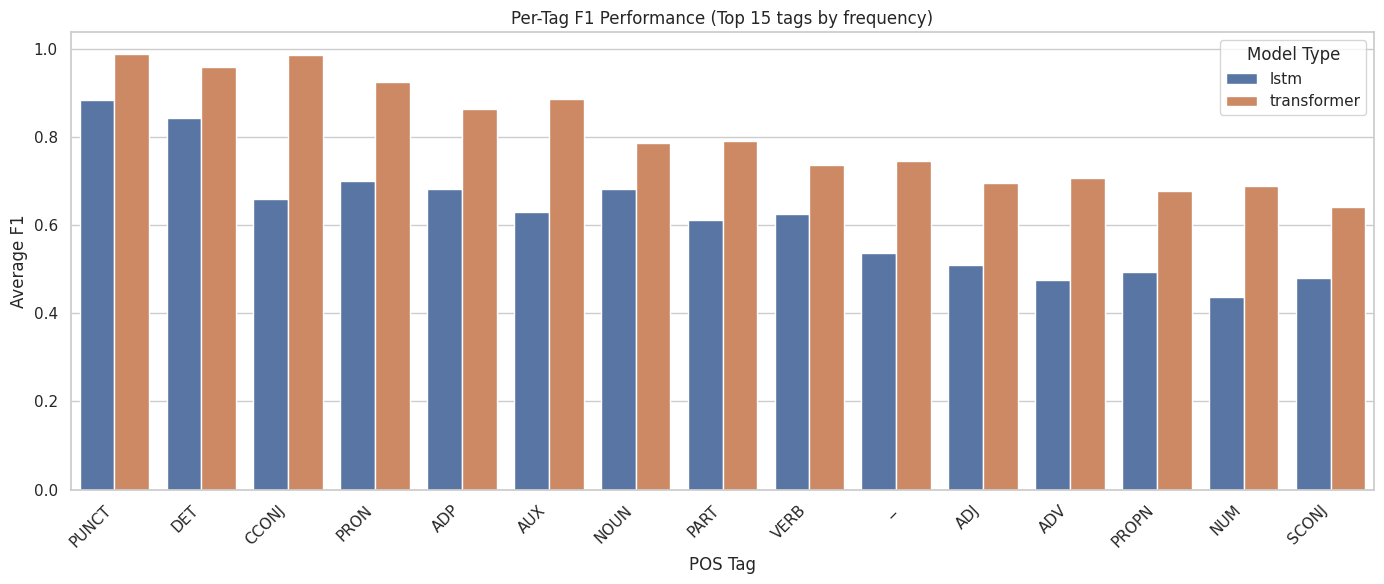

#### Tag-level comparison

**Best transformer: A_transformer_small_s13000**

,tag,f1,precision,recall,support
0,NOUN,0.851035,0.824713,0.879092,6385
1,NOUN,0.775589,0.716753,0.844949,6385
2,NOUN,0.849102,0.843007,0.855286,6385
3,PUNCT,0.993558,0.990207,0.996933,4564
4,PUNCT,0.987994,0.984341,0.991674,4564
5,PUNCT,0.992257,0.987839,0.996713,4564
6,VERB,0.822171,0.832061,0.812514,4427
7,VERB,0.741133,0.755931,0.726903,4427
8,VERB,0.812092,0.823502,0.800994,4427
9,PRON,0.950369,0.951178,0.949561,3529


**Best lstm: A_lstm_small_s13000**

,tag,f1,precision,recall,support
0,NOUN,0.900150,0.863264,0.940329,6385
1,PUNCT,0.993983,0.992572,0.995399,4564
2,VERB,0.908204,0.912449,0.903998,4427
3,PRON,0.980040,0.986227,0.973930,3529
4,ADP,0.939499,0.921921,0.957759,3267
5,DET,0.979184,0.967882,0.990753,2920
6,PROPN,0.794376,0.858092,0.739468,2445
7,AUX,0.959205,0.950566,0.968003,2344
8,ADJ,0.865997,0.849120,0.883559,2293
9,ADV,0.835896,0.888295,0.789335,1894


#### H2 hardest frequent tags

,tag,avg_f1,avg_precision,avg_recall,avg_support,runs
0,SCONJ,0.560103,0.625998,0.521557,534.8,15
1,NUM,0.562294,0.674725,0.509036,567.0,15
2,PROPN,0.584758,0.635232,0.569902,2004.2,15
3,ADV,0.591829,0.695373,0.539127,1177.8,15
4,ADJ,0.602493,0.638096,0.582174,1531.4,15
5,_,0.641269,0.752305,0.592589,284.6,15
6,VERB,0.680594,0.684541,0.683164,2877.8,15
7,PART,0.700546,0.643848,0.775852,697.4,15
8,NOUN,0.733815,0.675373,0.864815,4452.8,15
9,AUX,0.758115,0.779144,0.770882,1569.4,15


#### H2 tag spread by model family

,model_type,tag,mean_f1,std_f1,support
0,lstm,NUM,0.437278,0.402303,567.0
1,lstm,ADV,0.476193,0.398545,1177.8
2,lstm,SCONJ,0.480573,0.375211,534.8
3,lstm,PROPN,0.493493,0.371846,2004.2
4,lstm,ADJ,0.508789,0.389109,1531.4
5,lstm,_,0.536919,0.447810,284.6
6,lstm,PART,0.610656,0.448162,697.4
7,lstm,VERB,0.625713,0.337168,2877.8
8,lstm,AUX,0.629779,0.461199,1569.4
9,lstm,CCONJ,0.658993,0.480012,815.8


In [317]:
if not h2_data.empty:
    tag_df_h2 = plot_tag_performance(h2_data, MODELS_ROOT, metric="f1", top_n=15)

    if tag_df_h2 is not None and not tag_df_h2.empty:
        display(Markdown("#### Tag-level comparison"))
        for mt in h2_data["model_type"].unique():
            best_run = h2_data[h2_data["model_type"] == mt].nlargest(1, SELECTION_METRIC)
            if not best_run.empty:
                best_name = best_run.iloc[0]["name"]
                best_tags = tag_df_h2[tag_df_h2["name"] == best_name].nlargest(10, "support")
                if not best_tags.empty:
                    display(Markdown(f"**Best {mt}: {best_name}**"))
                    display(best_tags[["tag", "f1", "precision", "recall", "support"]].reset_index(drop=True))

        show_per_tag_tables(tag_df_h2, "H2", metric=SELECTION_METRIC)
else:
    print("No H2 data for tag analysis.")

## H1 vs H2 Metric Spread Comparison

This section compares numerical metric spreads between:
- H1 (large models)
- H2 (small models)

Spread metrics reported:
- `range` = max - min
- `std` = standard deviation
- `iqr` = Q3 - Q1

In [318]:
spread_metrics = ["f1", "token_accuracy", "best_val_accuracy", "best_val_loss", "train_time_sec"]
spread_metrics = [m for m in spread_metrics if m in df.columns]

def _metric_spread_table(df_subset, label, metrics):
    if df_subset.empty or not metrics:
        return pd.DataFrame()

    rows = []
    for metric in metrics:
        vals = pd.to_numeric(df_subset[metric], errors="coerce").dropna()
        if vals.empty:
            continue
        q1 = vals.quantile(0.25)
        q3 = vals.quantile(0.75)
        rows.append({
            "hypothesis_bucket": label,
            "metric": metric,
            "count": int(vals.shape[0]),
            "mean": vals.mean(),
            "std": vals.std(),
            "min": vals.min(),
            "q1": q1,
            "median": vals.median(),
            "q3": q3,
            "max": vals.max(),
            "range": vals.max() - vals.min(),
            "iqr": q3 - q1,
        })
    return pd.DataFrame(rows)

h1_spread = _metric_spread_table(h1_data, "H1_large", spread_metrics)
h2_spread = _metric_spread_table(h2_data, "H2_small", spread_metrics)
spread_compare = pd.concat([h1_spread, h2_spread], ignore_index=True)

if spread_compare.empty:
    print("No spread data available for H1/H2 comparison.")
else:
    display(Markdown("### Overall spread summary"))
    display(
        spread_compare.sort_values(["metric", "hypothesis_bucket"]).reset_index(drop=True)
    )

    if all(not x.empty for x in [h1_data, h2_data]):
        display(Markdown("### Relative spread (H2/H1)"))
        merged = h1_spread.merge(
            h2_spread,
            on="metric",
            suffixes=("_h1", "_h2"),
            how="inner",
        )
        for c in ["std", "range", "iqr"]:
            merged[f"{c}_ratio_h2_over_h1"] = merged.apply(
                lambda r: (r[f"{c}_h2"] / r[f"{c}_h1"]) if pd.notna(r[f"{c}_h1"]) and r[f"{c}_h1"] not in [0, 0.0] else np.nan,
                axis=1,
            )
        show_cols = [
            "metric",
            "std_h1", "std_h2", "std_ratio_h2_over_h1",
            "range_h1", "range_h2", "range_ratio_h2_over_h1",
            "iqr_h1", "iqr_h2", "iqr_ratio_h2_over_h1",
        ]
        show_cols = [c for c in show_cols if c in merged.columns]
        display(merged[show_cols].sort_values("metric").reset_index(drop=True))

    if all(c in h1_data.columns for c in ["model_type", "cfg_lr", "token_accuracy"]) and all(c in h2_data.columns for c in ["model_type", "cfg_lr", "token_accuracy"]):
        display(Markdown("### LR sensitivity comparison (token accuracy spread across LR)"))

        def _lr_sensitivity_table(df_subset, label):
            pivot = (
                df_subset.groupby(["model_type", "cfg_lr"], dropna=False)["token_accuracy"]
                .mean()
                .reset_index()
                .pivot(index="model_type", columns="cfg_lr", values="token_accuracy")
            )
            out = pivot.copy()
            out["lr_sensitivity"] = out.max(axis=1) - out.min(axis=1)
            out = out.reset_index()
            out.insert(0, "hypothesis_bucket", label)
            return out

        sens_h1 = _lr_sensitivity_table(h1_data, "H1_large")
        sens_h2 = _lr_sensitivity_table(h2_data, "H2_small")
        sens_compare = pd.concat([sens_h1, sens_h2], ignore_index=True)
        display(sens_compare)

### Overall spread summary

,hypothesis_bucket,metric,count,mean,std,min,q1,median,q3,max,range,iqr
0,H1_large,best_val_accuracy,30,0.858614,0.155482,0.368124,0.911233,0.920608,0.931639,0.939083,0.570960,0.020406
1,H2_small,best_val_accuracy,30,0.805613,0.227275,0.230328,0.857518,0.912441,0.929430,0.939833,0.709506,0.071913
2,H1_large,best_val_loss,30,0.490109,0.547682,0.198905,0.223024,0.266788,0.304817,2.192107,1.993202,0.081793
3,H2_small,best_val_loss,30,0.679480,0.760724,0.211520,0.245728,0.309892,0.551764,2.527947,2.316427,0.306036
4,H1_large,f1,30,0.805467,0.167641,0.291766,0.839441,0.858964,0.906280,0.923478,0.631712,0.066839
5,H2_small,f1,30,0.740478,0.241777,0.116130,0.736950,0.853134,0.870619,0.920030,0.803900,0.133669
6,H1_large,token_accuracy,30,0.817996,0.143754,0.360625,0.841584,0.860457,0.907181,0.924362,0.563737,0.065597
7,H2_small,token_accuracy,30,0.757593,0.213266,0.219764,0.745881,0.854150,0.871984,0.921758,0.701995,0.126103
8,H1_large,train_time_sec,30,62.224421,65.248874,11.167605,15.255353,31.810793,95.698083,249.328660,238.161056,80.442730
9,H2_small,train_time_sec,30,58.552544,61.757229,9.842432,14.189323,27.981028,91.021620,233.839791,223.997360,76.832297


### Relative spread (H2/H1)

,metric,std_h1,std_h2,std_ratio_h2_over_h1,range_h1,range_h2,range_ratio_h2_over_h1,iqr_h1,iqr_h2,iqr_ratio_h2_over_h1
0,best_val_accuracy,0.155482,0.227275,1.461747,0.570960,0.709506,1.242655,0.020406,0.071913,3.524028
1,best_val_loss,0.547682,0.760724,1.388990,1.993202,2.316427,1.162164,0.081793,0.306036,3.741604
2,f1,0.167641,0.241777,1.442236,0.631712,0.803900,1.272573,0.066839,0.133669,1.999869
3,token_accuracy,0.143754,0.213266,1.483545,0.563737,0.701995,1.245252,0.065597,0.126103,1.922384
4,train_time_sec,65.248874,61.757229,0.946487,238.161056,223.997360,0.940529,80.442730,76.832297,0.955118


### LR sensitivity comparison (token accuracy spread across LR)

cfg_lr,hypothesis_bucket,model_type,0.00001,0.0001,0.001,lr_sensitivity
0,H1_large,lstm,0.525862,0.908503,0.917758,0.391895
1,H1_large,transformer,0.836487,0.858287,0.861080,0.024592
2,H2_small,lstm,0.311451,0.841593,0.915017,0.603566
3,H2_small,transformer,0.760537,0.856703,0.860257,0.099721


# Hypothesis 3 — Best-Found Transformer vs Best-Found LSTM

**Research question**
With best-found LR per architecture, how does performance scale with more Brown data?

**Alternative hypothesis (H3)**
Transformer improves faster or reaches a higher asymptote than LSTM as sentence budget increases.

**Assumptions**
- Best LR chosen from H1/H2 is valid for Brown-domain runs.
- Brown preprocessing and tag mapping are stable across sentence budgets.
- Sentence sweep points are comparable without data leakage between train/val/test.

**Success criteria**
- Transformer is at least tied with LSTM at most sentence points.
- Transformer final large-budget point is higher than LSTM.
- Slope from first to last point is stronger for transformer or plateaus later than LSTM.

In [319]:
# Filter data for Hypothesis 3
h3_data = get_hypothesis(df, "H3_best_model_to_57k")

if h3_data.empty:
    print("No H3 data found yet. Run experiments with hypothesis='H3_best_model_to_57k' in config.")
else:
    print(f"Found {len(h3_data)} runs for Hypothesis 3")
    display(Markdown("### Hypothesis 3 — All runs"))
    display_cols = [
        "name", "model_type", "sentences", "cfg_lr",
        "f1", "token_accuracy", "best_val_accuracy",
        "train_time_sec", "num_params"
    ]
    display_cols = [c for c in display_cols if c in h3_data.columns]
    display(h3_data[display_cols].sort_values(["sentences", "model_type"]).reset_index(drop=True))

Found 10 runs for Hypothesis 3


### Hypothesis 3 — All runs

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params
0,A_lstm_stronger_s10000,lstm,10000,0.00100,0.928897,0.930085,0.934009,52.218484,3014522
1,A_transformer_medium_s10000,transformer,10000,0.00001,0.872452,0.874270,0.923958,48.544689,3135610
2,A_lstm_stronger_s22000,lstm,22000,0.00100,0.943646,0.944513,0.946410,85.818049,4451590
3,A_transformer_medium_s22000,transformer,22000,0.00001,0.896200,0.897812,0.934735,66.834885,4571142
4,A_lstm_stronger_s34000,lstm,34000,0.00100,0.955470,0.955892,0.955991,119.403538,5489294
5,A_transformer_medium_s34000,transformer,34000,0.00001,0.910018,0.911327,0.942580,88.537382,5607822
6,A_lstm_stronger_s46000,lstm,46000,0.00100,0.956559,0.957203,0.956404,144.668601,6167971
7,A_transformer_medium_s46000,transformer,46000,0.00001,0.914737,0.916124,0.946812,105.360122,6283811
8,A_lstm_stronger_s57000,lstm,57000,0.00100,0.957560,0.958070,0.958710,179.049430,6645430
9,A_transformer_medium_s57000,transformer,57000,0.00001,0.916678,0.917906,0.950435,123.930138,6758838


### Interpretation

**Expected outcomes:**
1. **Scaling behavior**:
   - Both models should improve with more data
   - Transformers expected to scale better (larger gains from 10k→30k)
   - LSTM gains may plateau earlier

2. **Brown corpus characteristics**:
   - Different tagset than UD
   - May have different difficulty profile
   
3. **Fixed optimal LR**:
   - Using 0.0001 (optimal from H1/H2)
   - Fair comparison of scaling without LR confound

### Visualization: Scaling Performance

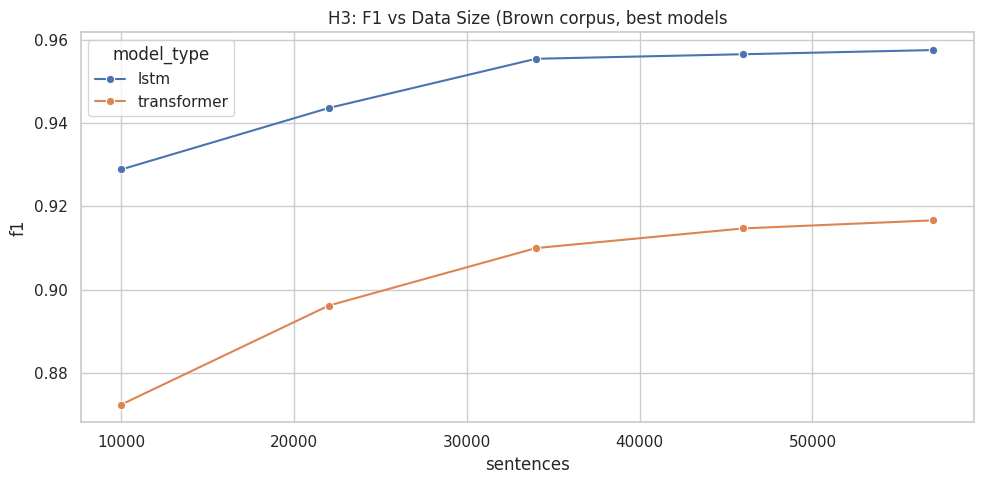

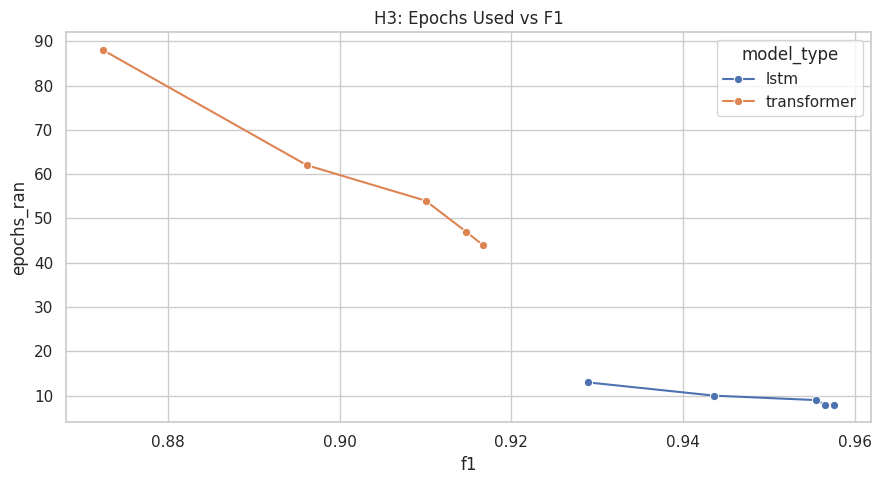

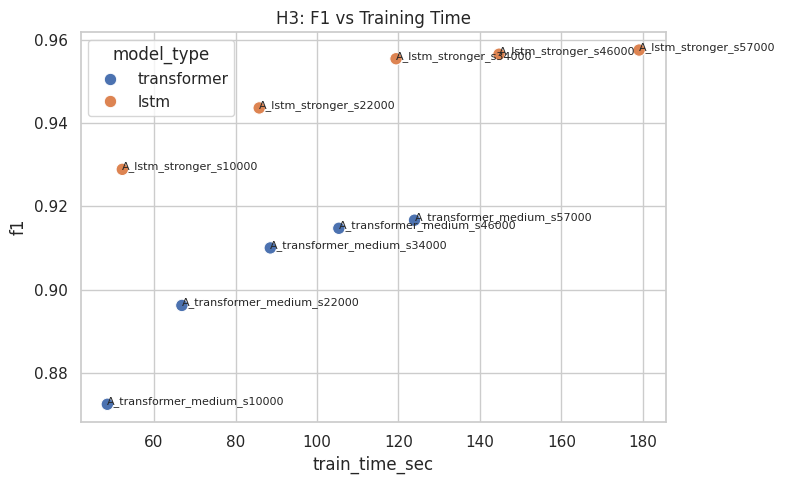

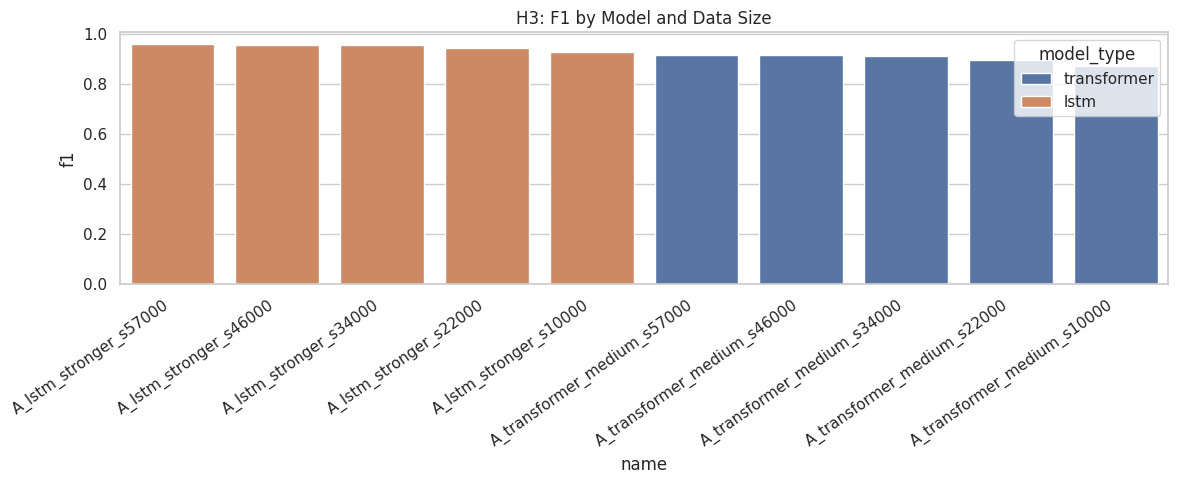

In [320]:
if not h3_data.empty:
    # Main scaling plot
    plot_line(
        h3_data,
        x="sentences",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H3: {SELECTION_METRIC.upper()} vs Data Size (Brown corpus, best models",
        figsize=(10, 5)
    )
    
    # Plot requested: epochs used vs F1 score
    if all(c in h3_data.columns for c in ["epochs_ran", SELECTION_METRIC]):
        plot_line(
            h3_data,
            x=SELECTION_METRIC,
            y="epochs_ran",
            hue="model_type",
            title="H3: Epochs Used vs " + SELECTION_METRIC.upper(),
            figsize=(9, 5)
        )
    else:
        print(f"Could not plot H3 epochs vs {SELECTION_METRIC} because 'epochs_ran' or '{SELECTION_METRIC}' is missing.")

    # Performance vs training time
    annotate_scatter(
        h3_data,
        x="train_time_sec",
        y=SELECTION_METRIC,
        title=f"H3: {SELECTION_METRIC.upper()} vs Training Time",
        figsize=(8, 5)
    )
    
    # Bar plot for direct comparison
    plot_bar(
        h3_data,
        metric=SELECTION_METRIC,
        title=f"H3: {SELECTION_METRIC.upper()} by Model and Data Size",
        hue="model_type",
        figsize=(12, 5)
    )

### Final tables

In [321]:
if not h3_data.empty:
    show_final_tables(h3_data, "H3", metric=SELECTION_METRIC)

    if all(c in h3_data.columns for c in ["model_type", "sentences", SELECTION_METRIC]):
        display(Markdown("#### H3 scaling gain from first to last sentence point"))
        gain_rows = []
        for mt in h3_data["model_type"].dropna().unique():
            mt_data = h3_data[h3_data["model_type"] == mt].sort_values("sentences")
            if len(mt_data) >= 2:
                first_val = mt_data.iloc[0][SELECTION_METRIC]
                last_val = mt_data.iloc[-1][SELECTION_METRIC]
                gain_rows.append({
                    "model_type": mt,
                    "first_sentences": mt_data.iloc[0]["sentences"],
                    "last_sentences": mt_data.iloc[-1]["sentences"],
                    "first_metric": first_val,
                    "last_metric": last_val,
                    "absolute_gain": last_val - first_val,
                    "percent_gain": ((last_val - first_val) / first_val) * 100 if first_val else np.nan,
                })
        display(pd.DataFrame(gain_rows).sort_values("absolute_gain", ascending=False).reset_index(drop=True))

#### H3 leaderboard (top 10 by f1)

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran
0,A_lstm_stronger_s57000,lstm,57000,0.00100,0.957560,0.958070,0.958710,0.141841,179.049430,6645430,8
1,A_lstm_stronger_s46000,lstm,46000,0.00100,0.956559,0.957203,0.956404,0.143470,144.668601,6167971,8
2,A_lstm_stronger_s34000,lstm,34000,0.00100,0.955470,0.955892,0.955991,0.152250,119.403538,5489294,9
3,A_lstm_stronger_s22000,lstm,22000,0.00100,0.943646,0.944513,0.946410,0.186243,85.818049,4451590,10
4,A_lstm_stronger_s10000,lstm,10000,0.00100,0.928897,0.930085,0.934009,0.233693,52.218484,3014522,13
5,A_transformer_medium_s57000,transformer,57000,0.00001,0.916678,0.917906,0.950435,0.177334,123.930138,6758838,44
6,A_transformer_medium_s46000,transformer,46000,0.00001,0.914737,0.916124,0.946812,0.193209,105.360122,6283811,47
7,A_transformer_medium_s34000,transformer,34000,0.00001,0.910018,0.911327,0.942580,0.214229,88.537382,5607822,54
8,A_transformer_medium_s22000,transformer,22000,0.00001,0.896200,0.897812,0.934735,0.245474,66.834885,4571142,62
9,A_transformer_medium_s10000,transformer,10000,0.00001,0.872452,0.874270,0.923958,0.300697,48.544689,3135610,88


#### H3 grouped summary (model_type, cfg_lr)

,model_type,cfg_lr,f1_mean,f1_std,f1_max,token_accuracy_mean,token_accuracy_std,train_time_sec_mean
0,lstm,0.00100,0.948427,0.012282,0.957560,0.949153,0.011988,116.231620
1,transformer,0.00001,0.902017,0.018362,0.916678,0.903488,0.018131,86.641443


#### H3 per-sentence winner

,sentences,name,model_type,cfg_lr,f1
0,10000,A_lstm_stronger_s10000,lstm,0.001,0.928897
1,22000,A_lstm_stronger_s22000,lstm,0.001,0.943646
2,34000,A_lstm_stronger_s34000,lstm,0.001,0.955470
3,46000,A_lstm_stronger_s46000,lstm,0.001,0.956559
4,57000,A_lstm_stronger_s57000,lstm,0.001,0.957560


#### H3 scaling gain from first to last sentence point

,model_type,first_sentences,last_sentences,first_metric,last_metric,absolute_gain,percent_gain
0,transformer,10000,57000,0.872452,0.916678,0.044226,5.069189
1,lstm,10000,57000,0.928897,0.957560,0.028663,3.085674


### Hypothesis 3 — Per-Tag Performance

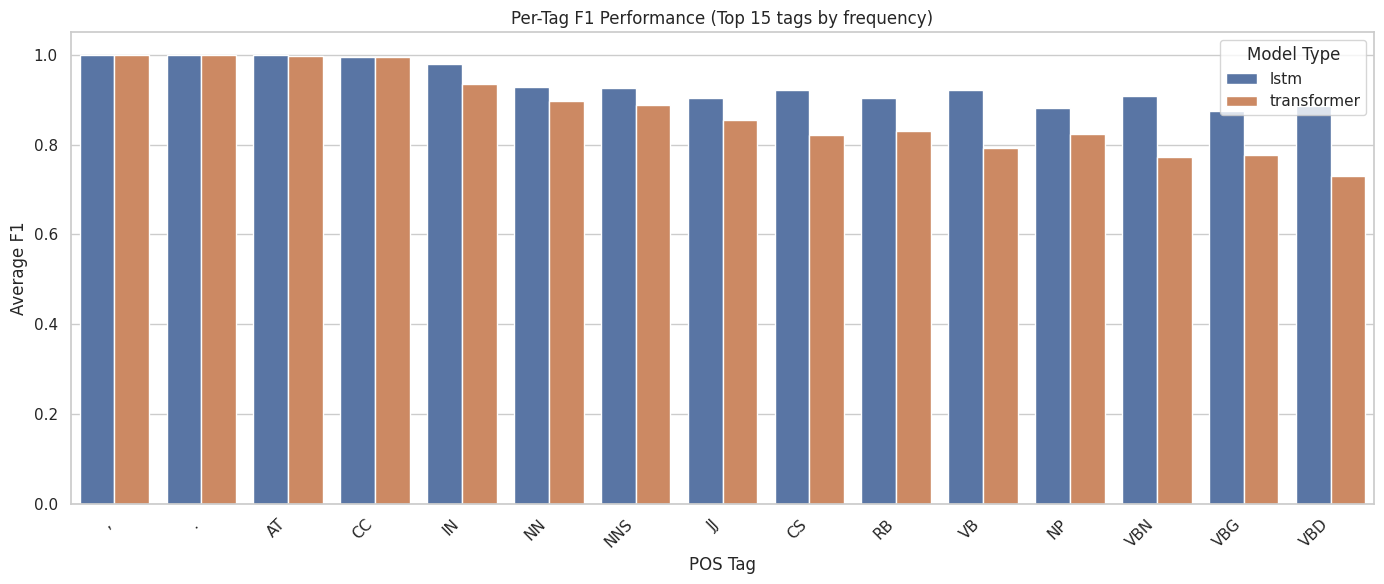

#### Tag-level comparison

**Best transformer: A_transformer_medium_s57000**

,tag,f1,precision,recall,support
0,NN,0.915322,0.911915,0.918753,29872
1,IN,0.936721,0.942386,0.931123,21502
2,AT,0.997590,0.995305,0.999885,17387
3,JJ,0.876252,0.863177,0.889730,12288
4,.,0.999504,1.000000,0.999008,12102
5,NNS,0.917748,0.909990,0.925640,10234
6,",",0.999850,0.999900,0.999799,9975
7,CC,0.994243,0.991714,0.996786,6844
8,NP,0.845412,0.853384,0.837588,6699
9,RB,0.852934,0.862189,0.843876,6450


**Best lstm: A_lstm_stronger_s57000**

,tag,f1,precision,recall,support
0,NN,0.937816,0.904321,0.973889,29872
1,IN,0.978526,0.977980,0.979072,21502
2,AT,0.998534,0.998104,0.998965,17387
3,JJ,0.919272,0.928234,0.910482,12288
4,.,0.999463,0.999917,0.999008,12102
5,NNS,0.949336,0.974385,0.925542,10234
6,",",0.999850,0.999900,0.999799,9975
7,CC,0.994377,0.994014,0.994740,6844
8,NP,0.894973,0.912248,0.878340,6699
9,RB,0.916212,0.920369,0.912093,6450


In [322]:
if not h3_data.empty:
    tag_df_h3 = plot_tag_performance(h3_data, MODELS_ROOT, metric="f1", top_n=15)

    if tag_df_h3 is not None and not tag_df_h3.empty:
        display(Markdown("#### Tag-level comparison"))
        for mt in h3_data["model_type"].unique():
            best_run = h3_data[h3_data["model_type"] == mt].nlargest(1, SELECTION_METRIC)
            if not best_run.empty:
                best_name = best_run.iloc[0]["name"]
                best_tags = tag_df_h3[tag_df_h3["name"] == best_name].nlargest(10, "support")
                if not best_tags.empty:
                    display(Markdown(f"**Best {mt}: {best_name}**"))
                    display(best_tags[["tag", "f1", "precision", "recall", "support"]].reset_index(drop=True))
else:
    print("No H3 data for tag analysis.")

# Hypothesis 3B — Large Sampled Dataset

**Research question**
How do best-found transformer and LSTM settings behave when training on larger sampled Brown subsets?

**Alternative hypothesis (H3B)**
Transformer remains more robust or improves more steadily than LSTM on larger sampled data budgets.

**Assumptions**
- Sampled subsets preserve a representative Brown tag distribution.
- Training pipeline and evaluation are identical to H3.
- Comparison is made at matched sentence budgets where available.

**Success criteria**
- Transformer is competitive at most sampled data points.
- Trend lines remain stable as sentence count increases.
- Final sampled-point score is not worse than the standard H3 trend expectation.

In [323]:
h3_sampling_data = get_hypothesis(df, "H3_best_model_sampling_to_105k")

if h3_sampling_data.empty:
    print("No H3 sampled data found yet. Run experiments with hypothesis='H3_best_model_sampling_to_105k' in config.")
else:
    print(f"Found {len(h3_sampling_data)} runs for Hypothesis 3B")
    display(Markdown("### Hypothesis 3B — All runs"))
    display_cols = [
        "name", "model_type", "sentences", "cfg_lr",
        "f1", "token_accuracy", "best_val_accuracy",
        "train_time_sec", "num_params"
    ]
    display_cols = [c for c in display_cols if c in h3_sampling_data.columns]
    display(h3_sampling_data[display_cols].sort_values(["sentences", "model_type"]).reset_index(drop=True))

Found 10 runs for Hypothesis 3B


### Hypothesis 3B — All runs

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params
0,A_lstm_stronger_s57000,lstm,57000,0.00100,0.957560,0.958070,0.958710,180.386126,6645430
1,A_transformer_medium_s57000,transformer,57000,0.00001,0.916683,0.917911,0.950442,125.914671,6758838
2,A_lstm_stronger_s69000,lstm,69000,0.00100,0.975145,0.975336,0.977120,218.087108,5732780
3,A_transformer_medium_s69000,transformer,69000,0.00001,0.941500,0.942394,0.965721,174.176263,5847468
4,A_lstm_stronger_s81000,lstm,81000,0.00100,0.977097,0.977240,0.979328,255.156552,5939503
5,A_transformer_medium_s81000,transformer,81000,0.00001,0.946501,0.947378,0.968866,204.773365,6053807
6,A_lstm_stronger_s93000,lstm,93000,0.00100,0.980967,0.981233,0.982428,327.189619,6093619
7,A_transformer_medium_s93000,transformer,93000,0.00001,0.952425,0.953269,0.972282,234.976030,6207411
8,A_lstm_stronger_s105000,lstm,105000,0.00100,0.983555,0.983715,0.985151,372.743220,6213044
9,A_transformer_medium_s105000,transformer,105000,0.00001,0.957443,0.958040,0.975443,281.642526,6326708


### Visualization: Sampled-Data Scaling

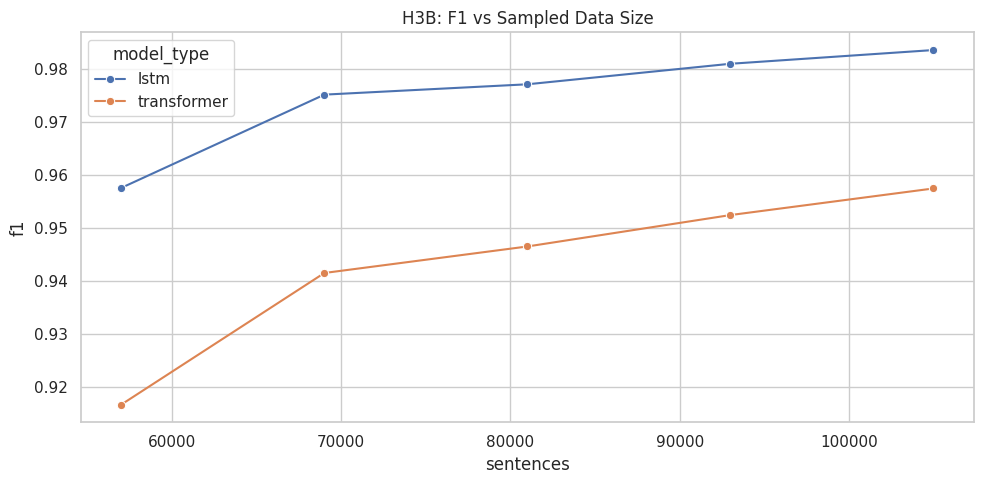

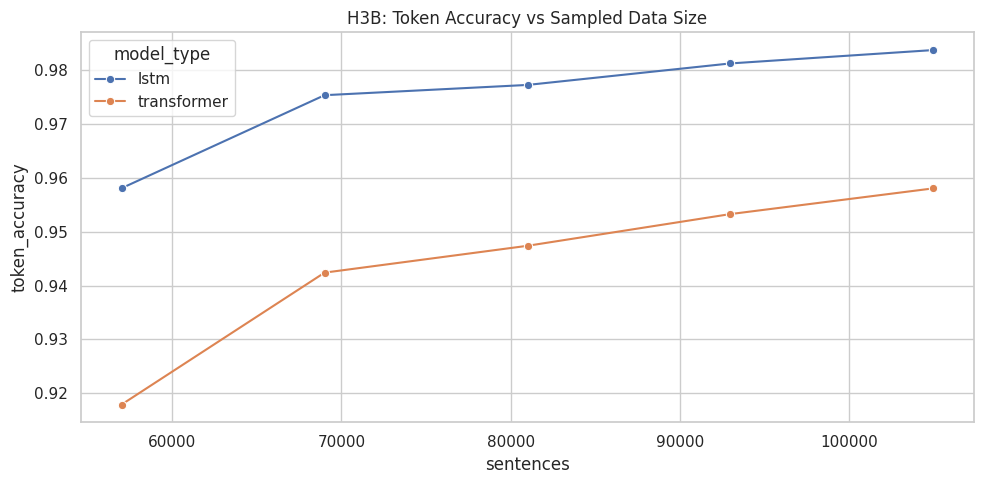

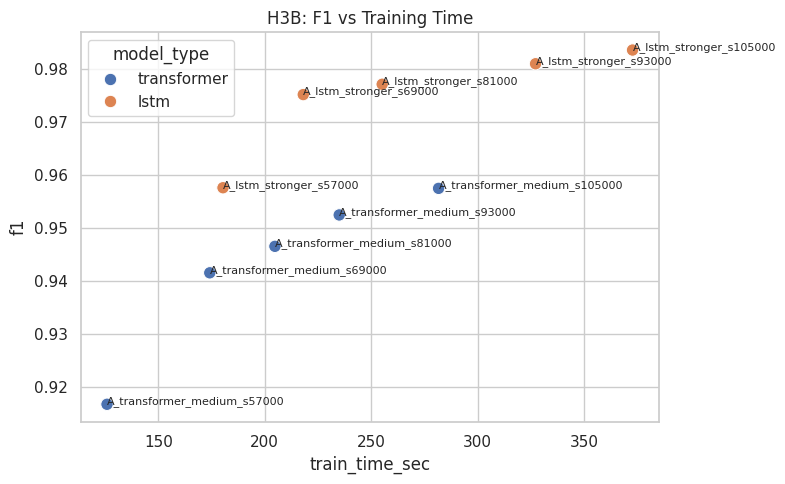

In [324]:
if not h3_sampling_data.empty:
    plot_line(
        h3_sampling_data,
        x="sentences",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H3B: {SELECTION_METRIC.upper()} vs Sampled Data Size",
        figsize=(10, 5)
    )

    if "token_accuracy" in h3_sampling_data.columns:
        plot_line(
            h3_sampling_data,
            x="sentences",
            y="token_accuracy",
            hue="model_type",
            title="H3B: Token Accuracy vs Sampled Data Size",
            figsize=(10, 5)
        )

    annotate_scatter(
        h3_sampling_data,
        x="train_time_sec",
        y=SELECTION_METRIC,
        title=f"H3B: {SELECTION_METRIC.upper()} vs Training Time",
        figsize=(8, 5)
    )

### Hypothesis 3B — Per-Tag Performance

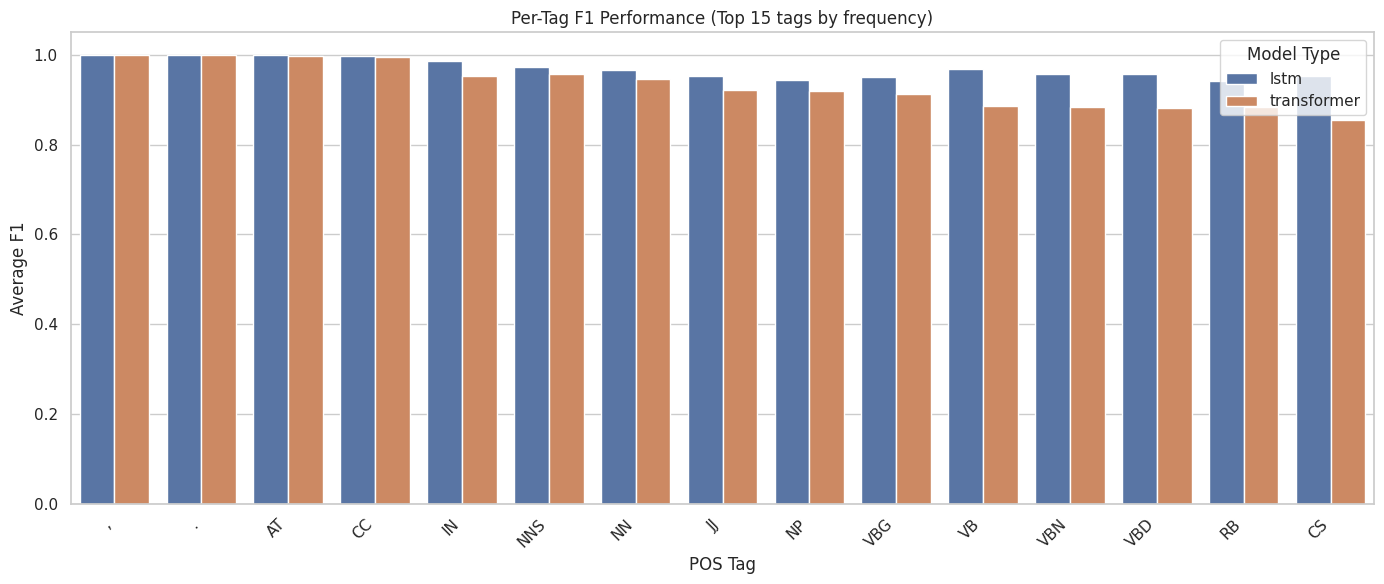

#### Tag-level comparison

**Best transformer: A_transformer_medium_s105000**

,tag,f1,precision,recall,support
0,NN,0.963040,0.961078,0.965011,54988
1,IN,0.961454,0.960306,0.962605,39684
2,AT,0.998399,0.997210,0.999591,31823
3,.,0.999420,0.999866,0.998975,22443
4,JJ,0.948791,0.948685,0.948896,22425
5,NNS,0.974063,0.974421,0.973706,19092
6,",",0.999946,1.000000,0.999892,18588
7,CC,0.995681,0.993060,0.998316,12470
8,NP,0.957019,0.962647,0.951457,12216
9,RB,0.904105,0.909559,0.898716,11996


**Best lstm: A_lstm_stronger_s105000**

,tag,f1,precision,recall,support
0,NN,0.980619,0.976245,0.985033,54988
1,IN,0.991378,0.990418,0.992339,39684
2,AT,0.999261,0.999466,0.999057,31823
3,.,0.999933,0.999866,1.000000,22443
4,JJ,0.970461,0.969597,0.971327,22425
5,NNS,0.983645,0.989194,0.978158,19092
6,",",0.999946,1.000000,0.999892,18588
7,CC,0.997554,0.997434,0.997674,12470
8,NP,0.966320,0.963841,0.968811,12216
9,RB,0.954566,0.943490,0.965905,11996


#### H3B hardest frequent tags

,tag,avg_f1,avg_precision,avg_recall,avg_support,runs
0,CS,0.904023,0.879845,0.931665,5231.6,10
1,RB,0.913276,0.916366,0.910352,9209.8,10
2,VBD,0.919216,0.920881,0.917639,6760.0,10
3,VBN,0.920622,0.916420,0.924968,7600.6,10
4,VB,0.926410,0.930258,0.922708,8688.6,10
5,VBG,0.930861,0.934947,0.927033,4700.6,10
6,NP,0.931684,0.940532,0.923089,9597.0,10
7,JJ,0.937209,0.933108,0.941462,17369.4,10
8,NN,0.956372,0.948118,0.964985,42728.4,10
9,NNS,0.964468,0.969637,0.959520,14754.0,10


#### H3B tag spread by model family

,model_type,tag,mean_f1,std_f1,support
0,lstm,RB,0.942564,0.015272,9209.8
1,lstm,NP,0.943970,0.028549,9597.0
2,lstm,VBG,0.949815,0.025174,4700.6
3,lstm,JJ,0.952071,0.020053,17369.4
4,lstm,CS,0.953157,0.015245,5231.6
5,lstm,VBD,0.956020,0.019345,6760.0
6,lstm,VBN,0.957029,0.017039,7600.6
7,lstm,NN,0.966020,0.016593,42728.4
8,lstm,VB,0.967432,0.011947,8688.6
9,lstm,NNS,0.972619,0.013659,14754.0


In [325]:
if not h3_sampling_data.empty:
    tag_df_h3_sampling = plot_tag_performance(h3_sampling_data, MODELS_ROOT, metric="f1", top_n=15)

    if tag_df_h3_sampling is not None and not tag_df_h3_sampling.empty:
        display(Markdown("#### Tag-level comparison"))
        for mt in h3_sampling_data["model_type"].unique():
            best_run = h3_sampling_data[h3_sampling_data["model_type"] == mt].nlargest(1, SELECTION_METRIC)
            if not best_run.empty:
                best_name = best_run.iloc[0]["name"]
                best_tags = tag_df_h3_sampling[tag_df_h3_sampling["name"] == best_name].nlargest(10, "support")
                if not best_tags.empty:
                    display(Markdown(f"**Best {mt}: {best_name}**"))
                    display(best_tags[["tag", "f1", "precision", "recall", "support"]].reset_index(drop=True))

        show_per_tag_tables(tag_df_h3_sampling, "H3B", metric=SELECTION_METRIC)
else:
    print("No H3 sampled data for tag analysis.")

### Final tables

In [326]:
if not h3_sampling_data.empty:
    show_final_tables(h3_sampling_data, "H3_best_model_sampling_to_105k", metric=SELECTION_METRIC)

    if all(c in h3_sampling_data.columns for c in ["model_type", "sentences", SELECTION_METRIC]):
        display(Markdown("#### H3B scaling gain from first to last sampled point"))
        gain_rows = []
        for mt in h3_sampling_data["model_type"].dropna().unique():
            mt_data = h3_sampling_data[h3_sampling_data["model_type"] == mt].sort_values("sentences")
            if len(mt_data) >= 2:
                first_val = mt_data.iloc[0][SELECTION_METRIC]
                last_val = mt_data.iloc[-1][SELECTION_METRIC]
                gain_rows.append({
                    "model_type": mt,
                    "first_sentences": mt_data.iloc[0]["sentences"],
                    "last_sentences": mt_data.iloc[-1]["sentences"],
                    "first_metric": first_val,
                    "last_metric": last_val,
                    "absolute_gain": last_val - first_val,
                    "percent_gain": ((last_val - first_val) / first_val) * 100 if first_val else np.nan,
                })
        display(pd.DataFrame(gain_rows).sort_values("absolute_gain", ascending=False).reset_index(drop=True))

#### H3_best_model_sampling_to_105k leaderboard (top 10 by f1)

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,best_val_loss,train_time_sec,num_params,epochs_ran
0,A_lstm_stronger_s105000,lstm,105000,0.00100,0.983555,0.983715,0.985151,0.062917,372.743220,6213044,9
1,A_lstm_stronger_s93000,lstm,93000,0.00100,0.980967,0.981233,0.982428,0.074443,327.189619,6093619,9
2,A_lstm_stronger_s81000,lstm,81000,0.00100,0.977097,0.977240,0.979328,0.080979,255.156552,5939503,8
3,A_lstm_stronger_s69000,lstm,69000,0.00100,0.975145,0.975336,0.977120,0.088832,218.087108,5732780,8
4,A_lstm_stronger_s57000,lstm,57000,0.00100,0.957560,0.958070,0.958710,0.141841,180.386126,6645430,8
5,A_transformer_medium_s105000,transformer,105000,0.00001,0.957443,0.958040,0.975443,0.093014,281.642526,6326708,58
6,A_transformer_medium_s93000,transformer,93000,0.00001,0.952425,0.953269,0.972282,0.104057,234.976030,6207411,55
7,A_transformer_medium_s81000,transformer,81000,0.00001,0.946501,0.947378,0.968866,0.114078,204.773365,6053807,55
8,A_transformer_medium_s69000,transformer,69000,0.00001,0.941500,0.942394,0.965721,0.125169,174.176263,5847468,55
9,A_transformer_medium_s57000,transformer,57000,0.00001,0.916683,0.917911,0.950442,0.177333,125.914671,6758838,44


#### H3_best_model_sampling_to_105k grouped summary (model_type, cfg_lr)

,model_type,cfg_lr,f1_mean,f1_std,f1_max,token_accuracy_mean,token_accuracy_std,train_time_sec_mean
0,lstm,0.00100,0.974865,0.010213,0.983555,0.975119,0.010081,270.712525
1,transformer,0.00001,0.942910,0.015847,0.957443,0.943798,0.015632,204.296571


#### H3_best_model_sampling_to_105k per-sentence winner

,sentences,name,model_type,cfg_lr,f1
0,57000,A_lstm_stronger_s57000,lstm,0.001,0.957560
1,69000,A_lstm_stronger_s69000,lstm,0.001,0.975145
2,81000,A_lstm_stronger_s81000,lstm,0.001,0.977097
3,93000,A_lstm_stronger_s93000,lstm,0.001,0.980967
4,105000,A_lstm_stronger_s105000,lstm,0.001,0.983555


#### H3B scaling gain from first to last sampled point

,model_type,first_sentences,last_sentences,first_metric,last_metric,absolute_gain,percent_gain
0,transformer,57000,105000,0.916683,0.957443,0.040760,4.446485
1,lstm,57000,105000,0.957560,0.983555,0.025994,2.714656
